In [1]:
import json
import re
from statistics import mean
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network
import IPython.display as display
import plotly.graph_objects as go

# I. Random Accuracy Study

## 1. MetaQA

In [2]:
metaqa = json.load(open("data/metaqa/baseline/standard/test.json", "r"))
res_metaqa = json.load(open("data/results/metaqa/eval_metaqa.json", "r"))["samples"]

In [3]:
acc = sum([1 for sample in res_metaqa if sample["gold"] == sample["pred"]]) / len(metaqa)
print("Test Accuracy: " + str(round(acc*100, 2)) + "%")

Test Accuracy: 10.05%


In [4]:
r_probs = []
for sample in metaqa:
    question = sample["question"]
    # Extract potential answers from the question (entities in triples)
    pattern = r'\(\s*([^,]+?)\s*,\s*([^,]+?)\s*,\s*([^,]+?)\s*\)'
    result = re.findall(pattern, question)
    # Filter out the header (s, p, o) and extract target entities
    potential_answers = [item[2].strip() for item in result if not (item[0].strip() == 's' and item[1].strip() == 'p')]
    unique_potential_answers = list(set(potential_answers))
    random_prob = 1/len(unique_potential_answers) if unique_potential_answers else 0
    r_probs.append(random_prob)
print("Random Chance: " + str(round(mean(r_probs)*100, 2)) + "%") if r_probs else print(0)

Random Chance: 5.51%


## 2. GSM8K 

In [5]:
with open('data/results/gsm8k/eval_samples.jsonl', 'r') as json_file:
    json_list = list(json_file)

gsm = []
for json_str in json_list:
    result = json.loads(json_str)
    gsm.append(result)
print(f"Total GSM8K samples loaded: {len(gsm)}")

Total GSM8K samples loaded: 448


In [6]:
acc = sum(sample["parsed"] == sample["ground_truth"] for sample in gsm) / len(gsm) if gsm else 0
print(f"GSM8K Accuracy: {acc*100:.2f}%")

GSM8K Accuracy: 0.89%


# II. MetaQA, KQA Pro differences and similarities with GraphQA
#### Why does HRM performs better than baseline on GraphQA and MetaQA and not on KQA Pro

## 1. MetaQA

In [7]:
metaqa = json.load(open("data/metaqa/baseline/standard/test.json", "r"))
res_metaqa = json.load(open("data/results/metaqa/eval_metaqa.json", "r"))["samples"]

In [8]:
metaqa_lengths = [len(sample["question"].split()) for sample in metaqa]
metaqa_answer_lengths = [len(sample["answer"].split()) for sample in metaqa]

df_metaqa = pd.DataFrame({
    "question_length": metaqa_lengths,
    "answer_length": metaqa_answer_lengths
})

print("MetaQA question length stats:")
print("Min:", df_metaqa["question_length"].min())
print("Max:", df_metaqa["question_length"].max())
print("Average:", df_metaqa["question_length"].mean())

print("MetaQA answer length stats:")
print("Min:", df_metaqa["answer_length"].min())
print("Max:", df_metaqa["answer_length"].max())
print("Average:", df_metaqa["answer_length"].mean())

MetaQA question length stats:
Min: 46
Max: 672
Average: 484.24706867671694
MetaQA answer length stats:
Min: 1
Max: 8
Average: 1.5510887772194304


In [23]:
question = metaqa[0]["question"]
answer = metaqa[0]["answer"]

pattern = r'\(\s*([^()]+?)\s*,\s+([^()]+?)\s*,\s+([^()]+?)\s*\)'
triples = re.findall(pattern, question)

G = nx.DiGraph()

# 2. Add edges with relation labels
for source, relation, target in triples:
    G.add_edge(source.strip(), target.strip(), label=relation.strip())

In [30]:
print(question)
print(answer)

In a knowledge graph, (s, p, o) means that entity s is linked to entity o by relation p.
The facts are:
(Zindagi Na Milegi Dobara, starred actors, Kalki Koechlin)
(Evil, written by, Mikael Håfström)
(Saawariya, starred actors, Salman Khan)
(The Strange Case of Angelica, directed by, Manoel de Oliveira)
(Blood for Dracula, directed by, Paul Morrissey)
(Tatie Danielle, directed by, Étienne Chatiliez)
(Tere Naam, starred actors, Salman Khan)
(Shanghai, directed by, Mikael Håfström)
(Insidious, directed by, James Wan)
(Road, Movie, release year, 2009)
(Tere Naam, written by, Bala)
(The Sure Thing, starred actors, John Cusack)
(Shanghai, release year, 2012)
(Tere Naam, directed by, Satish Kaushik)
(The Journey of Natty Gann, starred actors, John Cusack)
(Shanghai, written by, Dibakar Banerjee)
(Poltergeist III, directed by, Gary Sherman)
(The Crusades, directed by, Cecil B. DeMille)
(Must Love Dogs, starred actors, John Cusack)
(Breakfast of Champions, directed by, Alan Rudolph)
(The Number

In [26]:
# Initialize PyVis Network
net = Network(height="600px", width="100%", directed=True)

# Load your existing NetworkX graph G
net.from_nx(G)

# # Enable interactive physics GUI controls (optional)
# net.show_buttons(filter_=['physics'])

# # Save and open in your browser
# net.write_html("interactive_graph.html")

In [29]:
# 1. Calculate positions for the NetworkX graph
pos = nx.spring_layout(G, seed=42)

# 2. Extract edge positions
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=1, color="#888"),
    hoverinfo="none",
    mode="lines",
)

# 3. Extract node positions and names
node_x = []
node_y = []
node_text = []
node_colors = []
for node in G.nodes():
    print(node)
    x, y = pos[node]
    node_x.append(x)

    node_color = "Green" if answer.split('.')[0] in node else "SkyBlue"
    node_colors.append(node_color)
    node_y.append(y)
    node_text.append(str(node))

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    text=node_text,
    textposition="top center",
    hoverinfo="text",
    marker=dict(size=20, color=node_colors, line_width=2),
)

# 4. Create interactive Plotly figure (pan, zoom, hover)
fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        showlegend=False,
        hovermode="closest",
        margin=dict(b=0, l=0, r=0, t=0),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    ),
)

fig.show()

s
o
Zindagi Na Milegi Dobara
Kalki Koechlin
Evil
Mikael Håfström
Saawariya
Salman Khan
The Strange Case of Angelica
Manoel de Oliveira
Blood for Dracula
Paul Morrissey
Tatie Danielle
Étienne Chatiliez
Tere Naam
Shanghai
Insidious
James Wan
Road
release year, 2009
Bala
The Sure Thing
John Cusack
2012
Satish Kaushik
The Journey of Natty Gann
Dibakar Banerjee
Poltergeist III
Gary Sherman
The Crusades
Cecil B. DeMille
Must Love Dogs
Breakfast of Champions
Alan Rudolph
The Numbers Station
Nacho Libre
Jared Hess
America's Sweethearts
starred actors, Abhay Deol
Main Prem Ki Diwani Hoon
Sooraj R. Barjatya
Brick Lane
2007
Naan Kadavul
Tannishtha Chatterjee
Autumn Ball
Veiko Õunpuu
starred actors, Tannishtha Chatterjee
Mujhse Shaadi Karogi
True Colors
Hindi
2003
Laura Jones
One Crazy Summer
Thriller
Light Years Away
Alain Tanner
Equinox
Jack Woods
The Paperboy
The Frozen Ground
Drama
Saw
The Old Lady and the Pigeons
Sylvain Chomet
Hot Tub Time Machine
Down Terrace
Ben Wheatley
Mystery
Emraan Has

## 2. KQA Pro 

In [15]:
kqa = json.load(open("data/kqapro/baseline/standard/test.json", "r"))

In [16]:
kqa_lengths = [len(sample["question"].split()) for sample in kqa]
kqa_answer_lengths = [len(sample["answer"].split()) for sample in kqa]

df_kqa = pd.DataFrame({
    "question_length": kqa_lengths,
    "answer_length": kqa_answer_lengths
})

print("KQA question length stats:")
print("Min:", df_kqa["question_length"].min())
print("Max:", df_kqa["question_length"].max())
print("Average:", df_kqa["question_length"].mean())

print("KQA answer length stats:")
print("Min:", df_kqa["answer_length"].min())
print("Max:", df_kqa["answer_length"].max())
print("Average:", df_kqa["answer_length"].mean())

KQA question length stats:
Min: 52
Max: 1528
Average: 553.7954144620811
KQA answer length stats:
Min: 1
Max: 10
Average: 1.6657848324514992


## 3. GraphQA

## 4. Summary

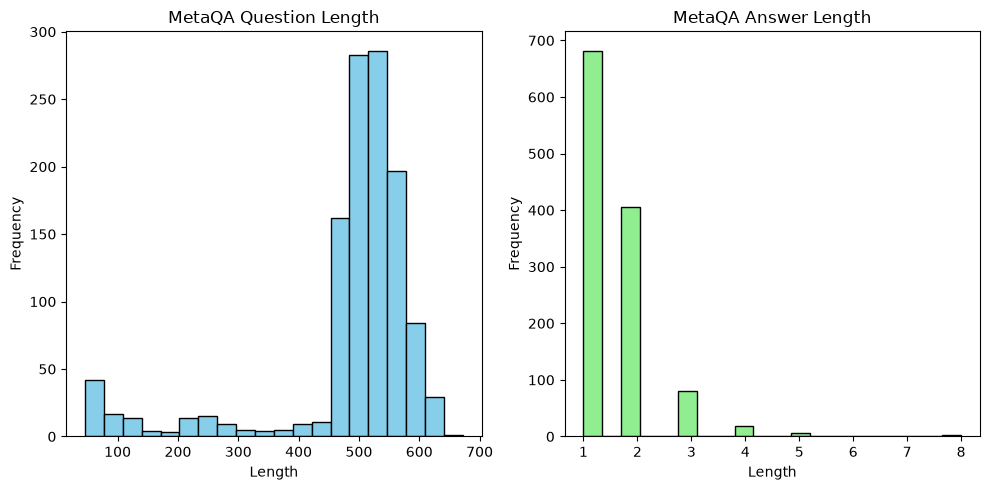

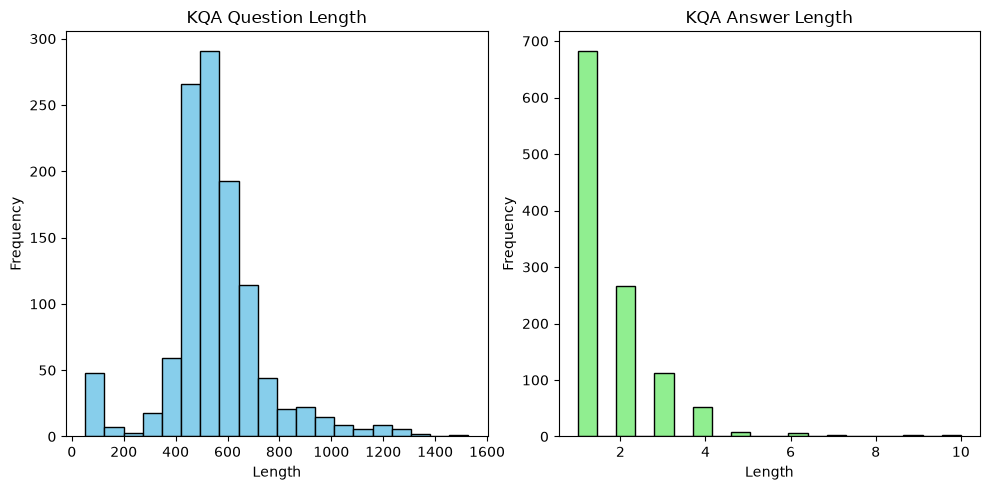

In [17]:
datasets = {
    "MetaQA": df_metaqa,
    "KQA": df_kqa
}

for dataset_name, df in datasets.items():
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(df["question_length"], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{dataset_name} Question Length")
    plt.xlabel("Length")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(df["answer_length"], bins=20, color='lightgreen', edgecolor='black')
    plt.title(f"{dataset_name} Answer Length")
    plt.xlabel("Length")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()